In [6]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [7]:
# Get project files
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.657.jpg  
  inflating: cats_and_dogs/train/dogs/dog.131.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.131.jpg  
  inflating: cats_and_dogs/train/dogs/dog.119.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.119.jpg  
  inflating: cats_and_dogs/train/dogs/dog.74.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.74.jpg  
  inflating: cats_and_dogs/train/dogs/dog.60.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_do

In [44]:
test_data_gen = test_image_generator.flow_from_directory(
    directory=test_dir,
    batch_size=1,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    shuffle=False
)

Found 0 images belonging to 0 classes.


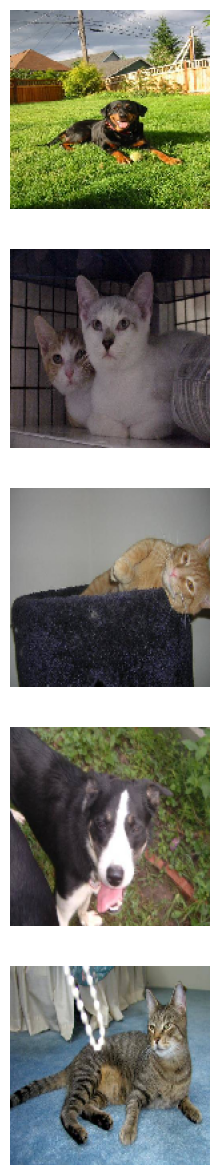

In [10]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [20]:
# 5
train_image_generator = None

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_image_generator = ImageDataGenerator(rescale=1./255)
test_image_generator = ImageDataGenerator(rescale=1./255)

Found 2000 images belonging to 2 classes.


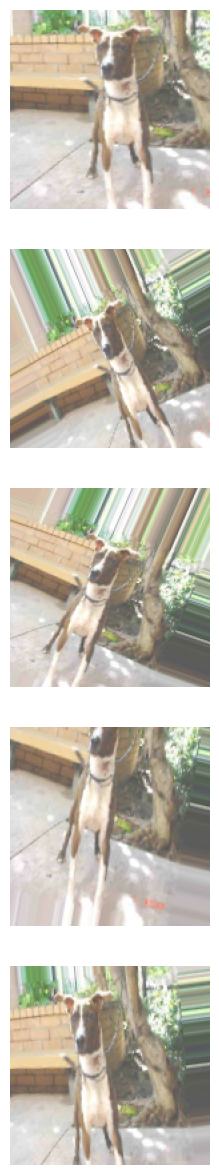

In [21]:
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [34]:
# 7
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
EPOCHS = 10

history = model.fit(
    train_data_gen,
    steps_per_epoch=len(train_data_gen),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=len(val_data_gen)
)


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 126s 8s/step - accuracy: 0.4995 - loss: 0.7715 - val_accuracy: 0.5010 - val_loss: 0.6919
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 132s 7s/step - accuracy: 0.5095 - loss: 0.6943 - val_accuracy: 0.5670 - val_loss: 0.6906
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 111s 7s/step - accuracy: 0.5320 - loss: 0.6929 - val_accuracy: 0.5100 - val_loss: 0.6916
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 150s 7s/step - accuracy: 0.5430 - loss: 0.6883 - val_accuracy: 0.5620 - val_loss: 0.6774
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 143s 8s/step - accuracy: 0.5625 - loss: 0.6830 - val_accuracy: 0.6030 - val_loss: 0.6665
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 133s 7s/step - accuracy: 0.5555 - loss: 0.6845 - val_accuracy: 0.6110 - val_loss: 0.6776
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.5910 - loss: 0.6784 - val_accuracy: 0.6040 - val_loss: 0.6538
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 114s 7s/step - accuracy: 0.6330 - loss: 0.6595 - val_accuracy: 0.6440 - v

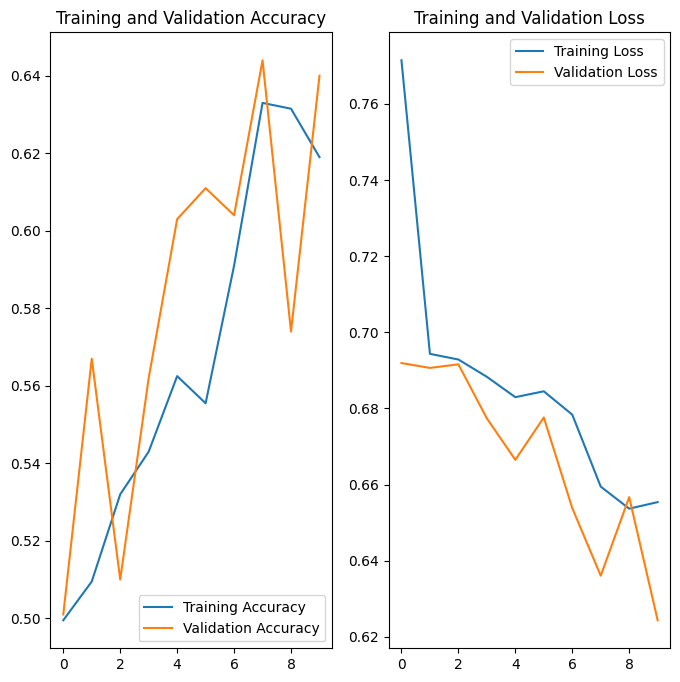

In [54]:
# 9
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [62]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

test_images = []

valid_extensions = ('.jpg', '.jpeg', '.png')

for img_name in sorted(os.listdir(test_dir)):
    if not img_name.lower().endswith(valid_extensions):
        continue

    img_path = os.path.join(test_dir, img_name)

    try:
        img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img = image.img_to_array(img)
        img = img / 255.0
        test_images.append(img)
    except:
        print("Bozuk dosya atlandı:", img_name)

test_images = np.array(test_images)

print("Loaded images:", len(test_images))

probabilities = model.predict(test_images)
probabilities = probabilities.flatten()


Loaded images: 50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step


In [47]:
import os
print(os.listdir(test_dir))


['28.jpg', '32.jpg', '29.jpg', '40.jpg', '50.jpg', '44.jpg', '.DS_Store', '43.jpg', '3.jpg', '18.jpg', '14.jpg', '45.jpg', '38.jpg', '16.jpg', '42.jpg', '36.jpg', '22.jpg', '9.jpg', '47.jpg', '11.jpg', '7.jpg', '4.jpg', '27.jpg', '10.jpg', '13.jpg', '19.jpg', '30.jpg', '5.jpg', '23.jpg', '26.jpg', '15.jpg', '17.jpg', '34.jpg', '2.jpg', '21.jpg', '1.jpg', '35.jpg', '25.jpg', '6.jpg', '12.jpg', '20.jpg', '37.jpg', '31.jpg', '33.jpg', '49.jpg', '48.jpg', '39.jpg', '24.jpg', '8.jpg', '46.jpg', '41.jpg']


In [63]:
import numpy as np

answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

if 'probabilities' not in globals():
    raise Exception("Önce CELL 10 (predict) çalıştır. probabilities yok!")

correct = 0

for probability, answer in zip(probabilities, answers):
    if round(probability) == answer:
        correct += 1

percentage_identified = (correct / len(answers)) * 100

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if percentage_identified >= 63:
    print("You passed the challenge!")
else:
    print("You haven't passed yet. Keep trying.")


Your model correctly identified 64.0% of the images of cats and dogs.
You passed the challenge!
